In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]],columns=['cgpa','profile_score','lpa'])

In [3]:
df

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [10]:
def initialize_parameter(layer_dims):

    np.random.seed(3)
    parameters={}
    L=len(layer_dims)

    for l in range(1,L):

        parameters['W'+str(l)]=np.ones((layer_dims[l-1],layer_dims[l]))*0.1
        parameters['b'+str(l)]=np.zeros((layer_dims[l],1))

    return parameters

In [11]:
initialize_parameter([2,2,1])

{'W1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[0.1],
        [0.1]]),
 'b2': array([[0.]])}

In [12]:
def linera_forward(A_prev,W,b):

    z=np.dot(W.T,A_prev)+b
    return z

In [13]:
#forward propagation
def L_layer_forward(X,parameters):

    A=X
    L=len(parameters)//2

    for l in range(1,L+1):
        A_prev=A
        W1=parameters['W'+str(l)]
        b1=parameters['b'+str(l)]
        print("A"+str(l-1)+": ",A_prev)
        print("W"+str(l)+": ",W1)
        print("b"+str(l)+": ",b1)
        print("--"*20)

        A=linera_forward(A_prev,W1,b1)
        print("A"+str(l)+": ",A)
        print("**"*20)

    return A,A_prev

In [14]:
X=df[['cgpa','profile_score']].values[0].reshape(2,1)
y=df[['lpa']].values[0][0]

In [17]:
parameters=initialize_parameter([2,2,1])
parameters

{'W1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[0.1],
        [0.1]]),
 'b2': array([[0.]])}

In [19]:
y_hat,A1=L_layer_forward(X,parameters)

A0:  [[8]
 [8]]
W1:  [[0.1 0.1]
 [0.1 0.1]]
b1:  [[0.]
 [0.]]
----------------------------------------
A1:  [[1.6]
 [1.6]]
****************************************
A1:  [[1.6]
 [1.6]]
W2:  [[0.1]
 [0.1]]
b2:  [[0.]]
----------------------------------------
A2:  [[0.32]]
****************************************


In [20]:
y_hat=y_hat[0][0]

In [21]:
A1

array([[1.6],
       [1.6]])

In [22]:
def update_parameters(parameters,y,y_hat,A1,X):
  parameters['W2'][0][0] = parameters['W2'][0][0] + (0.001 * 2 * (y - y_hat)*A1[0][0])
  parameters['W2'][1][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat)*A1[1][0])
  parameters['b2'][0][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat))

  parameters['W1'][0][0] = parameters['W1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[0][0])
  parameters['W1'][0][1] = parameters['W1'][0][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[1][0])
  parameters['b1'][0][0] = parameters['b1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0])

  parameters['W1'][1][0] = parameters['W1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[0][0])
  parameters['W1'][1][1] = parameters['W1'][1][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[1][0])
  parameters['b1'][1][0] = parameters['b1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0])

In [24]:
update_parameters(parameters,y,y_hat,A1,X)
parameters

{'W1': array([[0.11385611, 0.11385611],
        [0.11385611, 0.11385611]]),
 'b1': array([[0.00173201],
        [0.00173201]]),
 'W2': array([[0.123552],
        [0.123552]]),
 'b2': array([[0.130912]])}

In [25]:
X = df[['cgpa', 'profile_score']].values[1].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[1][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

A0:  [[7]
 [9]]
W1:  [[0.11385611 0.11385611]
 [0.11385611 0.11385611]]
b1:  [[0.00173201]
 [0.00173201]]
----------------------------------------
A1:  [[1.82342982]
 [1.82342982]]
****************************************
A1:  [[1.82342982]
 [1.82342982]]
W2:  [[0.123552]
 [0.123552]]
b2:  [[0.130912]]
----------------------------------------
A2:  [[0.5814888]]
****************************************


{'W1': array([[0.12249571, 0.12496417],
        [0.12249571, 0.12496417]]),
 'b1': array([[0.00296624],
        [0.00296624]]),
 'W2': array([[0.13966569],
        [0.13966569]]),
 'b2': array([[0.14850271]])}

In [26]:
X = df[['cgpa', 'profile_score']].values[2].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[2][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

A0:  [[ 6]
 [10]]
W1:  [[0.12249571 0.12496417]
 [0.12249571 0.12496417]]
b1:  [[0.00296624]
 [0.00296624]]
----------------------------------------
A1:  [[1.96289767]
 [2.002393  ]]
****************************************
A1:  [[1.96289767]
 [2.002393  ]]
W2:  [[0.13966569]
 [0.13966569]]
b2:  [[0.14850271]]
----------------------------------------
A2:  [[0.70231777]]
****************************************


{'W1': array([[0.13269672, 0.14196584],
        [0.13272332, 0.14201018]]),
 'b1': array([[0.00466641],
        [0.00467084]]),
 'W2': array([[0.16046331],
        [0.16088177]]),
 'b2': array([[0.17147714]])}

In [27]:
X = df[['cgpa', 'profile_score']].values[3].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[3][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

A0:  [[ 5]
 [12]]
W1:  [[0.13269672 0.14196584]
 [0.13272332 0.14201018]]
b1:  [[0.00466641]
 [0.00467084]]
----------------------------------------
A1:  [[2.26082985]
 [2.41862225]]
****************************************
A1:  [[2.26082985]
 [2.41862225]]
W2:  [[0.16046331]
 [0.16088177]]
b2:  [[0.17147714]]
----------------------------------------
A2:  [[0.92336961]]
****************************************


{'W1': array([[0.14411712, 0.16937482],
        [0.14428569, 0.16975986]]),
 'b1': array([[0.00695049],
        [0.00698332]]),
 'W2': array([[0.18793976],
        [0.19027592]]),
 'b2': array([[0.20242918]])}

In [28]:
# epochs implementation

parameters = initialize_parameter([2,2,1])
epochs = 5

for i in range(epochs):

  Loss = []

  for j in range(df.shape[0]):

    X = df[['cgpa', 'profile_score']].values[j].reshape(2,1) # Shape(no of features, no. of training example)
    y = df[['lpa']].values[j][0]

    # Parameter initialization


    y_hat,A1 = L_layer_forward(X,parameters)
    y_hat = y_hat[0][0]

    update_parameters(parameters,y,y_hat,A1,X)

    Loss.append((y-y_hat)**2)

  print('Epoch - ',i+1,'Loss - ',np.array(Loss).mean())

parameters

A0:  [[8]
 [8]]
W1:  [[0.1 0.1]
 [0.1 0.1]]
b1:  [[0.]
 [0.]]
----------------------------------------
A1:  [[1.6]
 [1.6]]
****************************************
A1:  [[1.6]
 [1.6]]
W2:  [[0.1]
 [0.1]]
b2:  [[0.]]
----------------------------------------
A2:  [[0.32]]
****************************************
A0:  [[7]
 [9]]
W1:  [[0.10658137 0.10658137]
 [0.10658137 0.10658137]]
b1:  [[0.00082267]
 [0.00082267]]
----------------------------------------
A1:  [[1.70612461]
 [1.70612461]]
****************************************
A1:  [[1.70612461]
 [1.70612461]]
W2:  [[0.111776]
 [0.111776]]
b2:  [[0.119136]]
----------------------------------------
A2:  [[0.50054357]]
****************************************
A0:  [[ 6]
 [10]]
W1:  [[0.11458955 0.1168776 ]
 [0.11458955 0.1168776 ]]
b1:  [[0.0019667]
 [0.0019667]]
----------------------------------------
A1:  [[1.83539945]
 [1.87200826]]
****************************************
A1:  [[1.83539945]
 [1.87200826]]
W2:  [[0.12712927]
 [0.127

{'W1': array([[0.26507636, 0.38558861],
        [0.27800387, 0.40980287]]),
 'b1': array([[0.02749056],
        [0.02974394]]),
 'W2': array([[0.41165744],
        [0.48302736]]),
 'b2': array([[0.48646246]])}

In [29]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [30]:
model=Sequential()
model.add(Dense(2,activation='linear',input_dim=2))
model.add(Dense(1,activation='linear'))

C:\Users\user\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.get_weights()

[array([[ 1.0217184 , -0.85266936],
        [ 0.3908373 ,  0.06730878]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.3801886],
        [ 0.9811574]], dtype=float32),
 array([0.], dtype=float32)]

In [34]:
optimizer=keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mean_squared_error',optimizer=optimizer)

In [35]:
model.fit(df.iloc[:,0:-1].values,df['lpa'].values,epochs=5,verbose=1,batch_size=1)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 609.2932
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 582.8320 
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 582.0831 
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 574.4321 
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 551.2823 


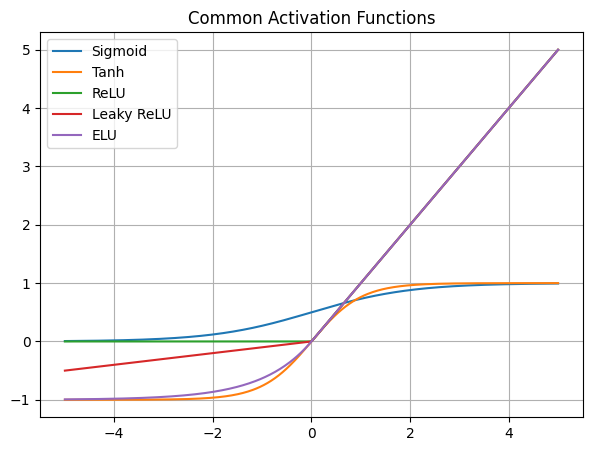

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 400)

# Activations
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.1*x)
elu = np.where(x > 0, x, 1.0*(np.exp(x)-1))

plt.figure(figsize=(7,5))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")
plt.plot(x, leaky_relu, label="Leaky ReLU")
plt.plot(x, elu, label="ELU")
plt.title("Common Activation Functions")
plt.legend()
plt.grid(True)
plt.show()
